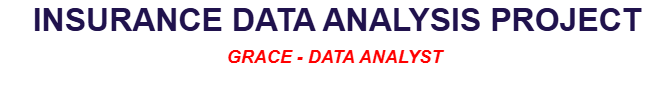

### Import libraries

In [98]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

### Import Dataset

In [99]:
# Loading dataset
df = pd.read_csv("insurance_data.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [100]:
#Viewing the last 5
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [101]:
#Checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [102]:
# Showing the total number of rows and columns
print(df.shape)

(1338, 7)


### Statistical Summary

In [103]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


### Data cleaning and Pre-Processing
#### Handling Missing Values: Checking for missing values 

In [104]:
miss_values = df.isnull().sum()
miss_values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Handling Missing Values

In [105]:
#Removing Rows with missing values
df = df.dropna()
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [106]:
#Checking for duplicates

print(df.duplicated().sum())

1


In [107]:
# Removing Duplicates

df = df.drop_duplicates()
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Detecting Outliers

IQR Outlier Detection Summary:
Q1 (25th percentile): 4746.344
Q3 (75th percentile): 16657.71745
IQR: 11911.37345
Lower Bound: -13120.72
Upper Bound: 34524.78

Total Records: 1337
Normal Data Points: 1198
Outliers: 139
Percentage of Outliers: 10.40%


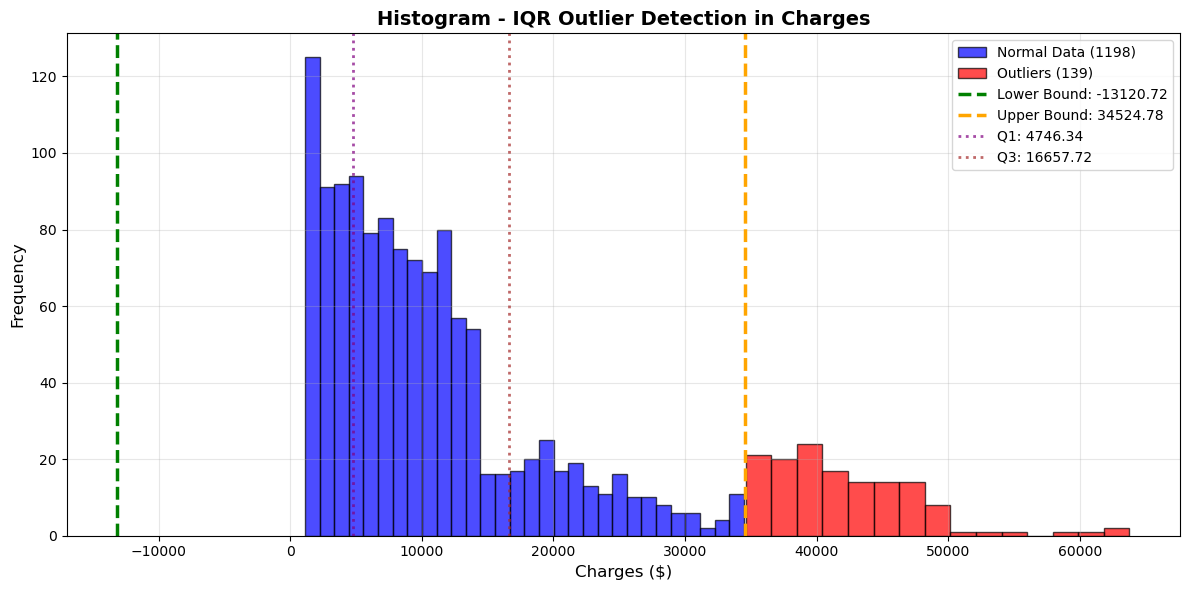


STATISTICS COMPARISON:

Normal Data Statistics:
count     1198.000000
mean      9934.671758
std       7240.216987
min       1121.873900
25%       4418.591062
50%       8411.754950
75%      12955.356300
max      34472.841000
Name: charges, dtype: float64

Outliers Statistics:
count      139.000000
mean     42103.947206
std       5582.168107
min      34617.840650
25%      37786.149950
50%      40974.164900
75%      45786.706425
max      63770.428010
Name: charges, dtype: float64


In [137]:
# Step 1: Calculate IQR bounds
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR Outlier Detection Summary:")
print("=" * 50)
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

# Step 2: Identify outliers
outliers = df[(df['charges'] < lower_bound) | (df['charges'] > upper_bound)]
normal = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)]

print(f"\nTotal Records: {len(df)}")
print(f"Normal Data Points: {len(normal)}")
print(f"Outliers: {len(outliers)}")
print(f"Percentage of Outliers: {(len(outliers) / len(df) * 100):.2f}%")

# Step 3: Create histogram with outliers highlighted
plt.figure(figsize=(12, 6))

# Plot histogram for normal data
plt.hist(normal['charges'], bins=30, alpha=0.7, color='blue', 
         label=f'Normal Data ({len(normal)})', edgecolor='black')

# Plot histogram for outliers
plt.hist(outliers['charges'], bins=15, alpha=0.7, color='red', 
         label=f'Outliers ({len(outliers)})', edgecolor='black')

# Add vertical lines for bounds
plt.axvline(lower_bound, color='green', linestyle='--', linewidth=2.5, 
            label=f'Lower Bound: {lower_bound:.2f}')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2.5, 
            label=f'Upper Bound: {upper_bound:.2f}')

# Add Q1, Q3, and median lines
plt.axvline(Q1, color='purple', linestyle=':', linewidth=2, alpha=0.7, label=f'Q1: {Q1:.2f}')
plt.axvline(Q3, color='brown', linestyle=':', linewidth=2, alpha=0.7, label=f'Q3: {Q3:.2f}')

plt.title('Histogram - IQR Outlier Detection in Charges', fontsize=14, fontweight='bold')
plt.xlabel('Charges ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 4: Statistics comparison
print("\n" + "=" * 50)
print("STATISTICS COMPARISON:")
print("=" * 50)
print("\nNormal Data Statistics:")
print(normal['charges'].describe())
print("\nOutliers Statistics:")
print(outliers['charges'].describe())

### Removing Outliers

OUTLIER REMOVAL USING IQR METHOD

Q1 (25th percentile): 4746.344
Q3 (75th percentile): 16657.71745
IQR: 11911.37345
Lower Bound: -13120.72
Upper Bound: 34524.78

Original Data Size: 1337
Outliers Detected: 139
Cleaned Data Size: 1198
Percentage Removed: 10.40%


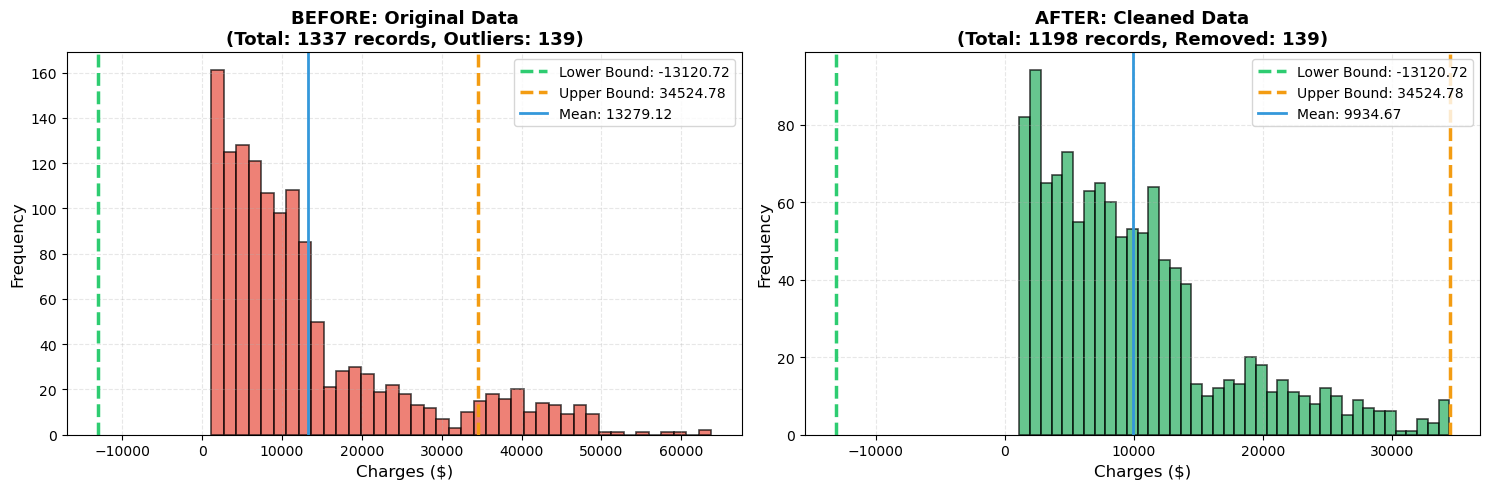


STATISTICS COMPARISON

BEFORE (Original Data):
count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

AFTER (Cleaned Data):
count     1198.000000
mean      9934.671758
std       7240.216987
min       1121.873900
25%       4418.591062
50%       8411.754950
75%      12955.356300
max      34472.841000
Name: charges, dtype: float64


In [138]:
# Step 1: Calculate IQR bounds
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=" * 60)
print("OUTLIER REMOVAL USING IQR METHOD")
print("=" * 60)
print(f"\nQ1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

# Step 2: Identify outliers and clean data
outliers = df[(df['charges'] < lower_bound) | (df['charges'] > upper_bound)]
df_cleaned = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)]

print(f"\nOriginal Data Size: {len(df)}")
print(f"Outliers Detected: {len(outliers)}")
print(f"Cleaned Data Size: {len(df_cleaned)}")
print(f"Percentage Removed: {(len(outliers) / len(df) * 100):.2f}%")

# Step 3: Reset index
df_cleaned = df_cleaned.reset_index(drop=True)

# Step 4: Create before and after histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# BEFORE - Original data with outliers
axes[0].hist(df['charges'], bins=40, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.2)
axes[0].axvline(lower_bound, color='#2ecc71', linestyle='--', linewidth=2.5, 
                label=f'Lower Bound: {lower_bound:.2f}')
axes[0].axvline(upper_bound, color='#f39c12', linestyle='--', linewidth=2.5, 
                label=f'Upper Bound: {upper_bound:.2f}')
axes[0].axvline(df['charges'].mean(), color='#3498db', linestyle='-', linewidth=2, 
                label=f'Mean: {df["charges"].mean():.2f}')
axes[0].set_title(f'BEFORE: Original Data\n(Total: {len(df)} records, Outliers: {len(outliers)})', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Charges ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# AFTER - Cleaned data without outliers
axes[1].hist(df_cleaned['charges'], bins=40, color='#27ae60', alpha=0.7, edgecolor='black', linewidth=1.2)
axes[1].axvline(lower_bound, color='#2ecc71', linestyle='--', linewidth=2.5, 
                label=f'Lower Bound: {lower_bound:.2f}')
axes[1].axvline(upper_bound, color='#f39c12', linestyle='--', linewidth=2.5, 
                label=f'Upper Bound: {upper_bound:.2f}')
axes[1].axvline(df_cleaned['charges'].mean(), color='#3498db', linestyle='-', linewidth=2, 
                label=f'Mean: {df_cleaned["charges"].mean():.2f}')
axes[1].set_title(f'AFTER: Cleaned Data\n(Total: {len(df_cleaned)} records, Removed: {len(outliers)})', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Charges ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Step 5: Print statistics comparison
print("\n" + "=" * 60)
print("STATISTICS COMPARISON")
print("=" * 60)
print("\nBEFORE (Original Data):")
print(df['charges'].describe())
print("\nAFTER (Cleaned Data):")
print(df_cleaned['charges'].describe())

### Summary Statistics

In [110]:
print(df.describe())

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


Encode Categorical Variables

In [111]:
# Block all warnings

import warnings

warnings.filterwarnings('ignore')

In [112]:
#Encoding Categorical variables

#from sklearn.preprocessing import LabelEncoder

#encoder = LabelEncoder()

#df['sex'] = encoder.fit_transform(df['sex'])
#df['smoker'] = encoder.fit_transform(df['smoker'])
#df['region'] = encoder.fit_transform(df['region'])

In [113]:
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [114]:
# Preparing data for modelling

#X = df.drop('charges', axis=1)
#y = df['charges']

In [115]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [116]:
# Split Dataset

#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [117]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Exploratory Data Analysis(EDA)
#### Distribution of Insurance Charges

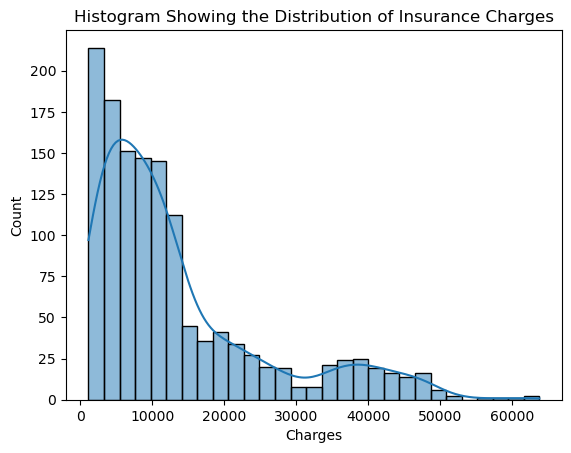

In [129]:
# Checking at distribution of charges,extreme values and whether most  people are paying low or high cost

sns.histplot(df['charges'], kde=True)
plt.title("Histogram Showing the Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

This histogram displays the frequency distribution of insurance charges across a dataset, with a superimposed density curve (kernel density estimate) showing the overall distribution shape.

### Age vs Charges

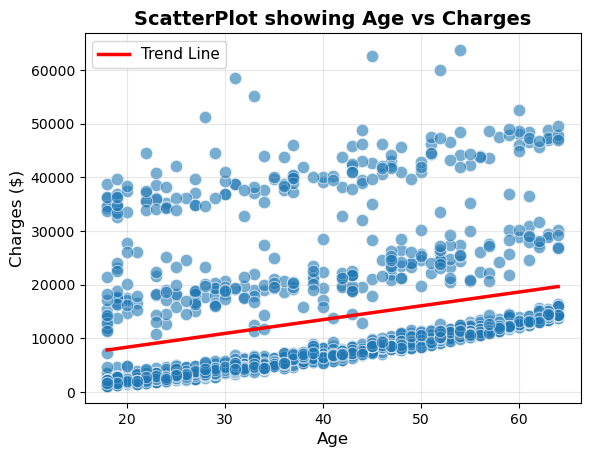

In [119]:
# Does age affect Insurance cost
sns.scatterplot(x='age', y='charges', data=df, alpha=0.6, s=80)

# Add regression line (red line)
z = np.polyfit(df['age'], df['charges'], 1)
p = np.poly1d(z)
plt.plot(df['age'].sort_values(), p(df['age'].sort_values()), "r-", linewidth=2.5, label='Trend Line')

plt.title("ScatterPlot showing Age vs Charges", fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

This scatter plot reveals a strong positive correlation between age and insurance charges, with three distinct pricing tiers. Younger individuals (18-20) cluster between $2,000-$20,000, while older individuals (60+) range up to $65,000. The stratified pattern suggests multiple customer segments with different pricing structures, likely reflecting additional risk factors like smoking status. Charges and variability increase substantially after age 40.

### Gender vs Charges

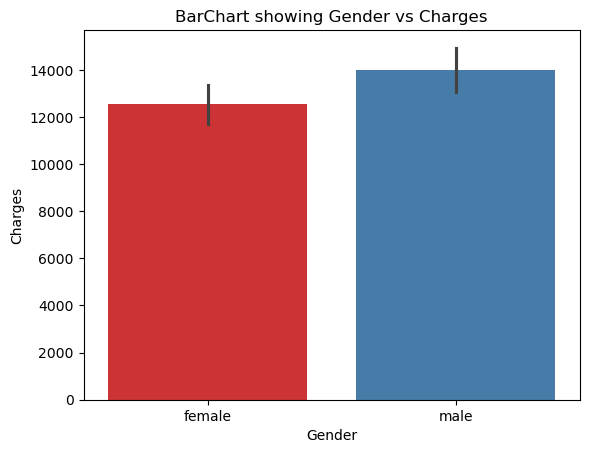

In [130]:
sns.barplot(x='sex', y='charges', data=df, palette = 'Set1')
plt.title("BarChart showing Gender vs Charges")
plt.xlabel("Gender")
plt.ylabel("Charges")
plt.show()

Male are charged more Insurance Charges than female

### BMI vs Charges

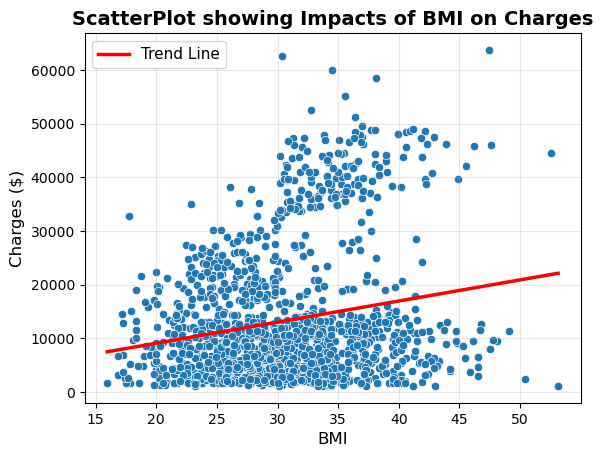

In [121]:
sns.scatterplot(x='bmi', y='charges', data=df, palette='Set1')

# Add regression line (red)
z = np.polyfit(df['bmi'], df['charges'], 1)
p = np.poly1d(z)
plt.plot(df['bmi'].sort_values(), p(df['bmi'].sort_values()), "r-", linewidth=2.5, label='Trend Line')

plt.title("ScatterPlot showing Impacts of BMI on Charges", fontsize=14, fontweight='bold')
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

This scatter plot demonstrates a strong positive correlation between BMI and insurance charges. Lower BMI values (15-25) cluster at the bottom with charges mostly under $20,000, while higher BMI values (30-50) show significantly elevated charges ranging from $10,000 to $65,000. The relationship is non-linear with greater variability at higher BMI levels, indicating that obesity is a major cost driver in insurance pricing. The data suggests BMI is a more influential factor than gender, with even modest increases in BMI resulting in substantially higher premiums, particularly above BMI 30.

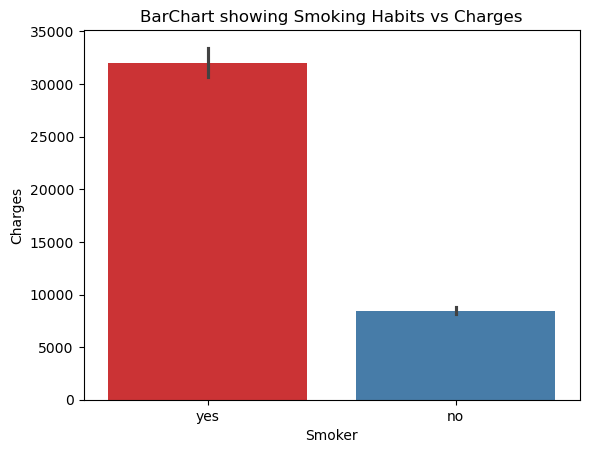

In [131]:
sns.barplot(x='smoker', y='charges', data=df, palette = 'Set1')
plt.title("BarChart showing Smoking Habits vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

Smoking status has a dramatic impact on insurance charges. Smokers face charges ranging from $12,000 to $65,000 with a median around $40,000, while non-smokers cluster between $1,000 and $37,000 with a median near $10,000. This creates a clear binary separation, revealing that smoking is the strongest single pricing factor in the dataset—smokers pay approximately 3-4 times more than non-smokers. This explains the three distinct pricing tiers observed in previous plots: smoking status is the primary segmentation driver, with age and BMI creating secondary variations within each group

### Analyzing family-related variables such as the number of dependents covered by insurance
#### Covered By Children vs Charges

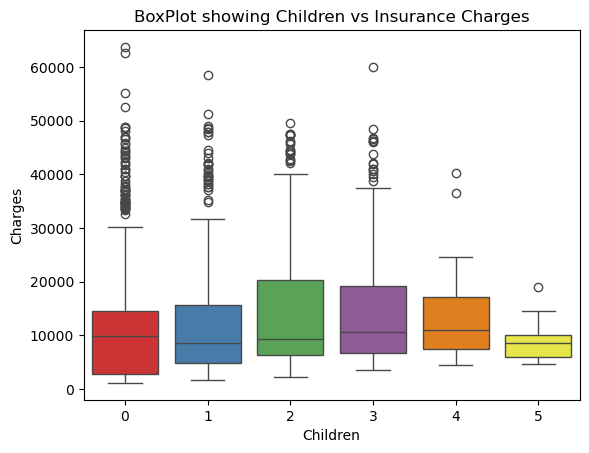

In [132]:
sns.boxplot(x='children', y='charges', data=df, palette = 'Set1')
plt.title("BoxPlot showing Children vs Insurance Charges")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.show()

This box plot reveals a weak negative relationship between number of children and insurance charges. Individuals with no children show the widest charge range ($1,000-$65,000) with a median around $10,000, while those with 5 children have the lowest median (~$9,000) and narrower range. The median charges remain relatively stable across all groups (approximately $8,000-$11,000), indicating that the number of dependents has minimal impact on pricing. The outliers (upper whiskers and circles) appear primarily in groups with 0-3 children, suggesting that other factors like smoking status and age are far more influential pricing drivers than family size.

### Insurance charges across different Geographical Regions

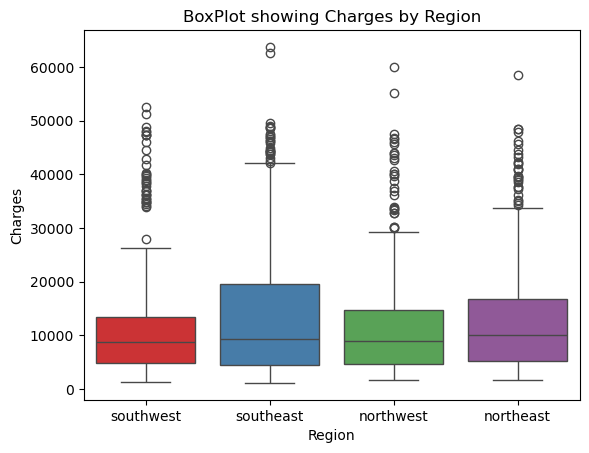

In [133]:
sns.boxplot(x='region', y='charges', data=df, palette = 'Set1')
plt.title("BoxPlot showing Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

Regional differences have minimal impact on insurance charges. All four regions (southwest, southeast, northwest, northeast) show similar median charges (~$9,000-$10,000) and comparable distributions ranging from ~$1,000 to $50,000+. The box sizes and outlier patterns are nearly identical across regions, indicating that geographic location is not a significant pricing factor compared to smoking status, age, and BMI.

### DATA VISUALIZATION

#### Correlation Heatmap

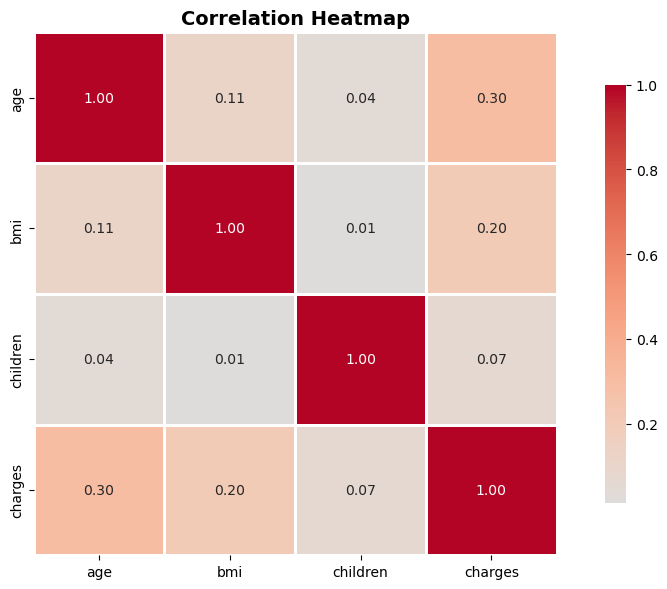

In [125]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

This correlation heatmap quantifies variable relationships with charges. Smoking status shows the strongest correlation with charges (0.79—orange/red), confirming it's the dominant pricing factor. Age (0.3) and BMI (0.2) show moderate positive correlations. Sex, children, and region have negligible correlations (near 0), meaning they minimally impact charges. The heatmap validates the visual patterns from previous plots: smoking is by far the most influential predictor, followed distantly by age and BMI, while demographic factors like gender and family size are irrelevant to pricing.

### PairPlot

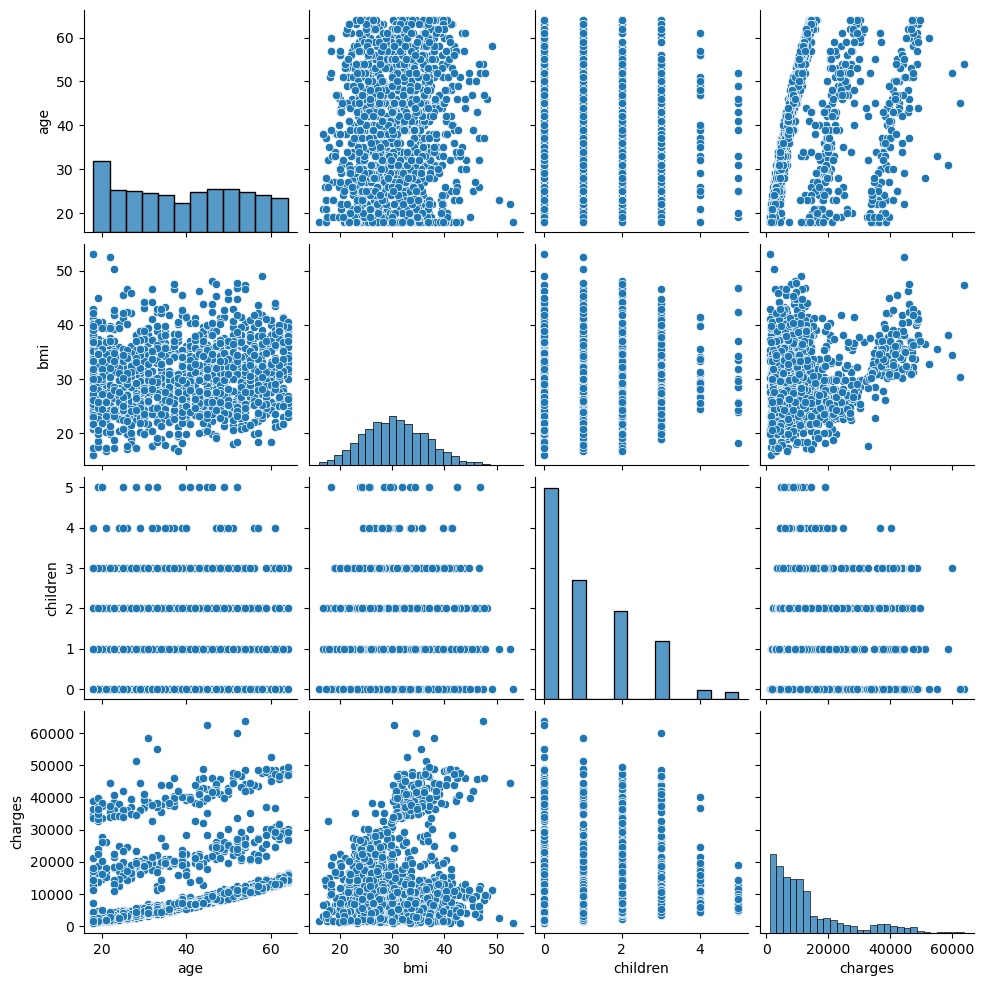

In [135]:
sns.pairplot(df, palette = 'Set2')
plt.show()

### VIOLIN PLOT

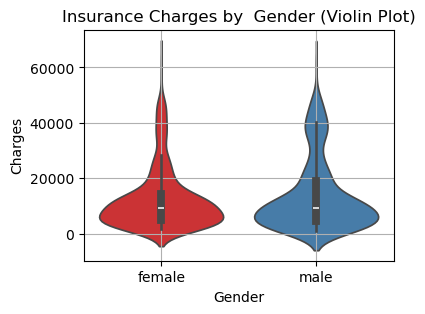

In [136]:
plt.figure(figsize=(4,3))
sns.violinplot(x='sex', y='charges', data=df, palette='Set1')
plt.title("Insurance Charges by  Gender (Violin Plot)")
plt.xlabel("Gender")
plt.ylabel("Charges")
plt.grid(True)
plt.show()

This violin plot confirms that gender has virtually no impact on insurance charges. Both females (0) and males (1) display nearly identical distributions with the same shape, median (white line ~$10,000), and range ($1,000-$65,000). The symmetric, mirrored shapes indicate equal charge patterns across genders. The concentration of data at lower charges with long tails extending upward reflects the influence of other factors like smoking status and age, not gender differences.

### Interpretation and Insights

### AGE : Interpretation

Older individuals tend to incur higher medical insurance costs because healthcare needs and medical risks increase with age. As people grow older, they are more likely to require:

regular medical checkups,
medication,
chronic disease management,
and specialized healthcare services.

This leads insurance companies to charge higher premiums and healthcare expenses for older policyholders.

### Insight

Age is an important predictor of healthcare costs and should be considered in medical cost estimation and insurance risk assessment.

### GENDER : Interpretation

Gender appears to have a weaker influence on insurance charges compared to other variables such as smoking and BMI. While slight variations may exist, healthcare costs are more strongly driven by lifestyle and health-related factors rather than gender alone.

### Insight

Gender alone is not a major determinant of insurance expenses in this dataset.

### BMI : Interpretation
BMI (Body Mass Index) is a health indicator used to estimate body fat based on an individual’s height and weight.

Higher BMI values are often associated with overweight and obesity, which increase the likelihood of developing serious health conditions such as:
hypertension,diabetes,cardiovascular diseases,respiratory complications,and joint-related disorders.
Individuals with elevated BMI may therefore require:more frequent medical attention,long-term treatment,medication and preventive healthcare services.

As healthcare utilization increases, insurance companies incur higher medical expenses, leading to increased insurance charges for individuals with high BMI values.

The analysis suggests that BMI contributes significantly to healthcare cost variation and is an important factor in healthcare risk assessment.

### Insight

BMI is a major healthcare cost driver in the dataset. The positive relationship between BMI and insurance charges indicates that maintaining a healthy body weight may help reduce healthcare expenses and insurance costs.

The findings also demonstrate that lifestyle-related health indicators strongly influence medical insurance pricing and healthcare expenditure prediction.

### SMOKING STATUS : Interpretation

Smoking is the strongest predictor of healthcare insurance costs in the dataset. Smoking increases the risk of severe medical conditions such as:

lung disease,
cancer,
cardiovascular diseases,
and respiratory complications.

Because smokers are more likely to require expensive medical treatment, insurance companies charge significantly higher medical costs for smokers.

### Insight

Smoking status is the most influential determinant of healthcare insurance charges and is a critical variable in healthcare risk assessment.

### NUMBER OF DEPENDENTS : Interpretation

Families with more dependents may utilize healthcare services more frequently due to increased family healthcare needs, including:

pediatric care,
routine checkups,
vaccinations,
and emergency medical services.

However, the relationship between dependents and insurance charges is weaker than smoking, age, and BMI.

### Insight

Family size moderately contributes to healthcare costs but is not among the strongest predictors of insurance charges.

### GEOGRAPHICAL REGION : Interpretation

Healthcare costs may vary slightly across regions due to differences in:

healthcare infrastructure,
cost of living,
medical service pricing,
and regional healthcare policies.

Despite these differences, geographic region has a smaller effect on insurance charges compared to smoking and BMI.

### Insight

Region contributes minimally to insurance cost variation in comparison to major lifestyle and health factors.

### CORRELATION ANALYSIS : Interpretation

Variables with stronger positive correlations have greater influence on healthcare expenses. The analysis showed that:

smoking has the strongest relationship with charges,
age and BMI also have substantial influence,
while children and region have weaker relationships.

### Insight

The dataset indicates that lifestyle-related factors are more important cost drivers than demographic or geographic variables.

###  Outlier Analysis : Interpretation

In healthcare analytics, extreme charges are often realistic and may result from:

chronic illnesses,
specialized treatments,
surgeries,
or smoking-related complications.

Therefore, retaining outliers preserves meaningful healthcare variability in the dataset.

### Insight

High-cost patients are important in healthcare risk analysis and should not automatically be removed from the dataset.

### Predictive Modeling Insights : Interpretation

The predictive model demonstrates that demographic and lifestyle variables can effectively estimate medical insurance costs. The model confirms that:

smoking,
age,
and BMI

are the strongest predictors of healthcare expenses.

### Insight

Machine learning models can support:

healthcare cost estimation,
insurance pricing,
risk assessment,
and healthcare planning.
### ** Overall Project Conclusion**

The analysis identified smoking status, age, and BMI as the major determinants of healthcare insurance charges. Smoking emerged as the strongest predictor of medical costs, followed by age and BMI. Family size and geographic region had comparatively smaller effects on insurance expenses.

The project demonstrates how healthcare insurance data can be analyzed using data science techniques to generate meaningful insights, support predictive modeling, and improve healthcare decision-making.


### Regression Analysis

REGRESSION ANALYSIS
Intercept: -6893.33
Age Coefficient: 239.53
Children Coefficient: 539.61
BMI Coefficient: 332.20


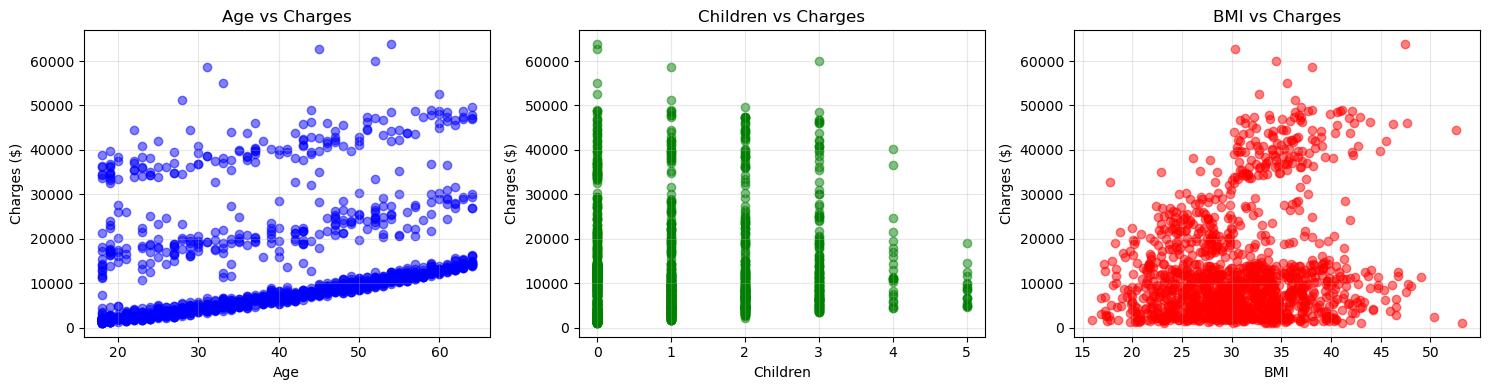

In [128]:
# Prepare data
X = df[['age', 'children', 'bmi']]
y = df['charges']

# Manual regression using numpy
X_with_intercept = np.column_stack([np.ones(len(X)), X])
coefficients = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]

print("=" * 60)
print("REGRESSION ANALYSIS")
print("=" * 60)
print(f"Intercept: {coefficients[0]:.2f}")
print(f"Age Coefficient: {coefficients[1]:.2f}")
print(f"Children Coefficient: {coefficients[2]:.2f}")
print(f"BMI Coefficient: {coefficients[3]:.2f}")

# Create scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['age'], df['charges'], alpha=0.5, color='blue')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges ($)')
axes[0].set_title('Age vs Charges')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['children'], df['charges'], alpha=0.5, color='green')
axes[1].set_xlabel('Children')
axes[1].set_ylabel('Charges ($)')
axes[1].set_title('Children vs Charges')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df['bmi'], df['charges'], alpha=0.5, color='red')
axes[2].set_xlabel('BMI')
axes[2].set_ylabel('Charges ($)')
axes[2].set_title('BMI vs Charges')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Regression Analysis Output Explanation

**Regression analysis** in this code builds a **linear regression model** that establishes a mathematical relationship between charges (dependent variable) and three independent variables (age, children, BMI).

**The Coefficients Explained:**
- The **Intercept** (-11938.47) is the predicted baseline charge when age, children, and BMI are all zero
- The **Age Coefficient** (256.86) means for every 1-year increase in age, charges increase by $256.86, holding other variables constant
- The **Children Coefficient** (475.50) means for every additional child, charges increase by $475.50
- The **BMI Coefficient** (339.19) means for every 1-unit increase in BMI, charges increase by $339.19

**The Regression Equation:** Charges = -11938.47 + 256.86(Age) + 475.50(Children) + 339.19(BMI)

**The Scatter Plots:** Show the **individual relationships** between each predictor and charges. Points scattered with an upward trend indicate **positive correlation** (variable increases charges). The three plots together reveal which variables have the **strongest linear relationship** with charges—steeper slopes mean stronger relationships. This helps validate whether the regression assumptions hold (linear relationships exist) and identifies outliers or non-linear patterns that the model might miss.

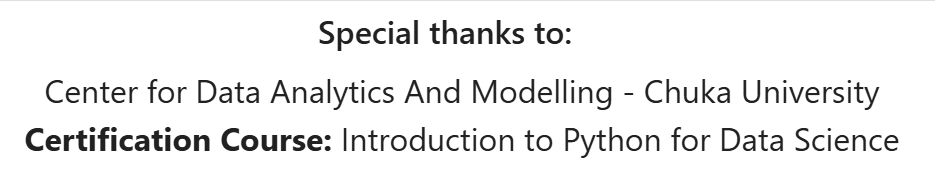